# Multi-Train-Size Kinematic Reconstruction Demo

Sweeps over training sizes `TRAIN_SIZES = [1, 3, 5, 10, 15, 20, 30, 50]` for a single heliostat.

**Splitting strategy** — all on-disk samples (train + val + test) are aggregated into one pool, then
re-split per training size using the PAINT **azimuth split**:
- `train` = first `N` samples (smallest azimuth = morning)
- `val`   = last `VAL_SIZE` samples (largest azimuth = late afternoon) — **fixed** across all sizes
- `test`  = middle slice (solar noon) — shrinks slightly as training grows

**Data modes**
| Mode | Source | GT perturbations? |
|---|---|---|
| `synthetic` | Pre-generated PNGs on disk | Yes — from `perturbations.json` |
| `random_synthetic` | Geometry from disk; flux/centroids/motor-pos regenerated in memory with fresh perturbations | Yes — newly sampled |
| `real` | PAINT calibration images | No |

**Training pipeline** (two stages, same as `one_heliostat_training_demo.ipynb`)
1. Stage 1 — AlignmentLoss (motor-position MSE, no ray tracing, fast)
2. Stage 2 — FocalSpotLoss (ray-traced centroid MSE, mini-batched)

**Outputs**
- Per-size: split polar plot, loss curves, accuracy table
- Summary: learning curve (mrad vs. training size), parameter recovery vs. GT

## Imports

In [1]:
import json
import pathlib
import sys
import warnings

import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as mgridspec
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from tqdm import tqdm as tqdm_nb

warnings.filterwarnings("ignore")

# Path setup — notebook lives in src/perturbation_visualizer/
_nb   = pathlib.Path(globals().get("__vsc_ipynb_file__", pathlib.Path().resolve() / "x")).parent
_src  = _nb.parent          # .../src
_base = _src.parent         # .../master-thesis
_repo = _base.parent        # .../Master Thesis
sys.path.insert(0, str(_src))
sys.path.insert(0, str(_repo / "PAINT"))  # for paint.data.dataset_splits

from artist.raytracing.heliostat_ray_tracer import HeliostatRayTracer
from artist.scenario.scenario import Scenario
from artist.util import get_device, set_logger_config, indices
from artist.optim.loss import FocalSpotLoss

from utils.synth_data import (
    _forward_pass,
    apply_perturbations,
    reset_perturbations,
    sample_perturbations,
    SyntheticDatasetParser,
)
from artist_extensions.loss_functions_ext import AlignmentLoss
from paint.data.dataset_splits import DatasetSplitter
import paint.util.paint_mappings as paint_mappings

set_logger_config()
import logging
logging.getLogger().setLevel(logging.WARNING)

print("Imports OK")

Imports OK


## Configuration

This is the single cell to change between experiments.

In [2]:
# ============================================================
#  CONFIG
# ============================================================

HELIOSTAT_ID       = "AO34"  # any ID present in one_heliostat_scenarios/ and the dataset
DATA_MODE          = "real"   # "synthetic" | "random_synthetic" | "real"
DATASET_SPLIT_TYPE = "azimuth_dataset"    # "azimuth_dataset" | "balanced_dataset"

# Training size sweep. Must satisfy: N + 2*VAL_SIZE <= N_TOTAL (checked per size).
TRAIN_SIZES = [1, 3, 5, 10, 15, 20, 30, 50, 75]
VAL_SIZE    = 100   # validation set size (fixed across all training sizes)

# Surface resolution (must match dataset generation)
SURFACE_POINTS_PER_FACET = 25   # 25x25 = 625 pts/facet

# Ray counts
TRAIN_RAYS   = 10    # rays per surface point during Stage 2 training
DISPLAY_RAYS = 50    # rays for evaluation snapshots
GENERATE_RAYS = 100  # rays for in-memory GT generation (random_synthetic only)

# Training schedule
STAGE1_EPOCHS   = 20
STAGE2_EPOCHS   = 100
MINI_BATCH_SIZE = 25    # Stage 2: max samples per ray-tracing mini-batch
BASE_LR         = 1e-4
SKIP_STAGE1     = False  # set True to skip Stage 1 (AlignmentLoss) and go straight to Stage 2

# Filter: discard GT flux images with fewer active pixels than this threshold
MIN_ACTIVE_PIXEL_PERCENT = 2.0

# Swap val and test splits after azimuth splitting.
# False (default): train=sunrise, val=sunset, test=solar-noon
# True:            train=sunrise, val=solar-noon, test=sunset
#   → sunset is never seen during training; tests whether the model generalises to it.
SWAP_VAL_TEST = True

# Perturbation sampling (random_synthetic mode only)
RANDOM_SEED = 42
RANDOM_PERT_BOUNDS = {
    "rotation_rad":       0.003,
    "actuator_angle_rad": 0.003,
    "actuator_stroke_m":  0.003,
    "actuator_offset_m":  0.003,
    "translation_m":      0.015,
    "base_position_m":    0.015,
}

# ---- Paths -------------------------------------------------------------------
SCENARIO_PATH     = _base / "scenarios" / "one_heliostat_scenarios" / HELIOSTAT_ID / "scenario.h5"
SYNTH_DATASET_DIR = _base / "datasets" / "synthetic" / DATASET_SPLIT_TYPE / "dataset"
PERTURBATIONS_JSON = SYNTH_DATASET_DIR / "perturbations.json"

# Real PAINT data paths (used when DATA_MODE = "real")
REAL_BENCHMARK_DIR = _base / "datasets" / "paint" / "benchmark_split-azimuth_train-100_validation-50_deflectometry"
REAL_SPLITS_CSV    = _base / "datasets" / "paint" / "splits"   / "benchmark_split-azimuth_train-100_validation-50_deflectometry.csv"
REAL_METADATA_CSV  = _base / "datasets" / "paint" / "metadata" / "calibration_metadata_all_heliostats.csv"

def _count_samples(split_name: str) -> int | None:
    d = SYNTH_DATASET_DIR / split_name / HELIOSTAT_ID
    if not d.exists():
        return None
    return sum(1 for p in d.iterdir() if p.is_dir())

if DATA_MODE in {"synthetic", "random_synthetic"}:
    N_DISK = {
        s: _count_samples(s) for s in ("train", "val", "test")
    }
    total = sum(v for v in N_DISK.values() if v)
    print(f"Dataset: {SYNTH_DATASET_DIR}")
    print(f"On-disk counts for {HELIOSTAT_ID}: {N_DISK}  →  pool = {total}")
    print(f"VAL_SIZE={VAL_SIZE},  max feasible train = {total - 2*VAL_SIZE}")
else:
    N_DISK = {}
    print(f"Real mode — benchmark: {REAL_BENCHMARK_DIR.name}")

Real mode — benchmark: benchmark_split-azimuth_train-100_validation-50_deflectometry


## Load Scenario

Loads the single-heliostat HDF5 scenario (clean, unperturbed) and computes the heliostat-to-tower distance.

In [3]:
device = get_device()
print(f"Device: {device}")

with h5py.File(SCENARIO_PATH, "r") as f:
    scenario = Scenario.load_scenario_from_hdf5(
        scenario_file=f,
        device=device,
        number_of_surface_points_per_facet=torch.tensor(
            [SURFACE_POINTS_PER_FACET, SURFACE_POINTS_PER_FACET]
        ),
    )

heliostat_group = scenario.heliostat_field.heliostat_groups[0]
kinematic       = heliostat_group.kinematics

# Heliostat-to-tower distance for mrad error computation
hel_pos      = heliostat_group.positions[0, :3].float()
_planar      = scenario.solar_tower.target_areas[indices.planar_target_areas]
tower_ref    = _planar.centers[:, :3].float().mean(dim=0).to(device)
hel_dist_m   = torch.norm(hel_pos - tower_ref).item()

print(f"Scenario : {SCENARIO_PATH}")
print(f"Heliostat: {HELIOSTAT_ID}  |  dist-to-tower = {hel_dist_m:.1f} m")

[2026-06-06 15:24:21,474][artist.util.env][INFO] - No device type provided. The device will default to GPU based on availability and OS, otherwise to CPU.
[2026-06-06 15:24:21,475][artist.util.env][WARNING] - Setting device to CPU. ARTIST only supports CPU for MacOS.
Device: cpu
[2026-06-06 15:24:21,479][artist.scenario.scenario][INFO] - Loading an ARTIST scenario HDF5 file. This scenario file is version 1.0.
[2026-06-06 15:24:21,481][artist.field.tower_target_areas_planar][INFO] - Loading the planar tower target areas from an HDF5 file.
[2026-06-06 15:24:21,488][artist.field.tower_target_areas_cylindrical][INFO] - Loading the cylindrical tower target areas from an HDF5 file.
[2026-06-06 15:24:21,493][artist.scene.light_source_array][INFO] - Loading a light source array from an HDF5 file.
[2026-06-06 15:24:21,494][artist.scene.sun][INFO] - Loading sun_1 from an HDF5 file.
[2026-06-06 15:24:21,497][artist.scene.sun][INFO] - Initializing a sun modeled with a multivariate normal distribut

## Load Full Pool

Loads **all** on-disk samples (train + val + test) and aggregates into one tensor pool.
For `random_synthetic`, regenerates motor positions, centroids, and flux with fresh perturbations.
The pool is then filtered and used by the DatasetSplitter for each training size.

In [4]:
# ============================================================
#  Load all splits into one aggregated pool
# ============================================================

def _parse_split(split_name: str, n: int):
    """Load n samples from split_name directory. Returns (flux, cents, rays, mp, tm)."""
    parser  = SyntheticDatasetParser(SYNTH_DATASET_DIR / split_name)
    mapping = [(HELIOSTAT_ID, list(range(n)), list(range(n)))]
    flux, cents, rays, mp, _am, tm = parser.parse_data_for_reconstruction(
        heliostat_data_mapping=mapping,
        heliostat_group=heliostat_group,
        scenario=scenario,
        device=device,
    )
    return flux, cents, rays, mp, tm

# all_datetimes: list[pd.Timestamp] for real data (used in splitting DataFrame),
#                None for synthetic (dummy timestamp used instead).
all_datetimes = None

if DATA_MODE in {"synthetic", "random_synthetic"}:
    parts = [
        _parse_split(s, n)
        for s, n in N_DISK.items() if n
    ]
    all_flux        = torch.cat([p[0] for p in parts], dim=0)
    all_centroids   = torch.cat([p[1] for p in parts], dim=0)
    all_rays        = torch.cat([p[2] for p in parts], dim=0)
    all_motor_pos   = torch.cat([p[3] for p in parts], dim=0)
    all_target_mask = torch.cat([p[4] for p in parts], dim=0)

else:
    # ---- Real PAINT data ------------------------------------------------
    # 1. Build file path lists for every sample that belongs to HELIOSTAT_ID,
    #    pooling all three original splits so the notebook can re-split freely.
    from artist_extensions.cached_paint_parser import CachedPaintCalibrationDataParser

    _splits_df = pd.read_csv(REAL_SPLITS_CSV)
    _meta_df   = pd.read_csv(REAL_METADATA_CSV)

    _ao_rows = _splits_df[_splits_df["HeliostatId"] == HELIOSTAT_ID]
    if _ao_rows.empty:
        raise ValueError(f"{HELIOSTAT_ID} not found in {REAL_SPLITS_CSV.name}")

    _sample_ids, _prop_paths, _png_paths = [], [], []
    _missing = 0
    for _, row in _ao_rows.iterrows():
        sid = row["Id"]
        sp  = row["Split"]   # "train" | "validation" | "test"
        png  = REAL_BENCHMARK_DIR / "flux_image"             / sp / f"{sid}-flux.png"
        prop = REAL_BENCHMARK_DIR / "calibration_properties" / sp / f"{sid}-calibration-properties.json"
        if png.exists() and prop.exists():
            _sample_ids.append(sid)
            _prop_paths.append(prop)
            _png_paths.append(png)
        else:
            _missing += 1

    print(f"Real data: found {len(_sample_ids)} files for {HELIOSTAT_ID}  "
          f"(skipped {_missing} missing on disk)")

    # 2. Parse — returns the same 6-tuple as SyntheticDatasetParser
    _parser  = CachedPaintCalibrationDataParser()
    _mapping = [(HELIOSTAT_ID, _prop_paths, _png_paths)]
    (all_flux, all_centroids, all_rays, all_motor_pos,
     _am_ignored, all_target_mask) = _parser.parse_data_for_reconstruction(
        heliostat_data_mapping=_mapping,
        heliostat_group=heliostat_group,
        scenario=scenario,
        device=device,
    )

    # 3. Real datetimes — join metadata on sample ID, in the same pool order.
    #    Used in the splitting DataFrame instead of a dummy timestamp.
    _meta_ao = _meta_df[_meta_df["HeliostatId"] == HELIOSTAT_ID].set_index("Id")
    all_datetimes = [
        pd.to_datetime(_meta_ao.loc[sid, "DateTime"], utc=True).tz_convert(None)
        if sid in _meta_ao.index
        else pd.Timestamp("2020-06-15 12:00:00")
        for sid in _sample_ids
    ]

    pert_tensors = None  # no GT perturbations for real data

N_POOL_RAW = all_flux.shape[0]
print(f"Raw pool: {N_POOL_RAW} samples  (flux shape: {tuple(all_flux.shape)})")

# ============================================================
#  random_synthetic: regenerate motor_pos + centroids + flux
#  with freshly sampled perturbations.
# ============================================================

pert_tensors = None   # set below for synthetic/random_synthetic

if DATA_MODE == "random_synthetic":
    pert_tensors   = sample_perturbations(1, RANDOM_PERT_BOUNDS, RANDOM_SEED)
    _orig_params   = apply_perturbations(kinematic, pert_tensors, device)
    _pool_active   = torch.tensor([N_POOL_RAW], device=device, dtype=torch.long)

    with torch.no_grad():
        heliostat_group.activate_heliostats(
            active_heliostats_mask=_pool_active, device=device
        )
        heliostat_group.align_surfaces_with_incident_ray_directions(
            aim_points=scenario.solar_tower.get_centers_of_target_areas(
                all_target_mask, device
            ),
            incident_ray_directions=all_rays,
            active_heliostats_mask=_pool_active,
            device=device,
        )
        all_motor_pos = kinematic.active_motor_positions.detach().clone()

        scenario.set_number_of_rays(GENERATE_RAYS)
        all_centroids, all_flux = _forward_pass(
            scenario, heliostat_group,
            all_rays, _pool_active, all_target_mask,
            torch.zeros(1, 3, device=device), device,
        )
        scenario.set_number_of_rays(TRAIN_RAYS)

    reset_perturbations(kinematic, _orig_params)
    print(f"random_synthetic: regenerated motor_pos, centroids, flux for {N_POOL_RAW} samples")

elif DATA_MODE == "synthetic":
    with open(PERTURBATIONS_JSON) as fh:
        _pj = json.load(fh)
    _hd = _pj[HELIOSTAT_ID]
    pert_tensors = {
        "translation":     torch.tensor(_hd["translation_m"],      device=device).unsqueeze(0),
        "rotation":        torch.tensor(_hd["rotation_rad"],        device=device).unsqueeze(0),
        "actuator_angle":  torch.tensor(_hd["actuator_angle_rad"],  device=device).unsqueeze(0),
        "actuator_stroke": torch.tensor(_hd["actuator_stroke_m"],   device=device).unsqueeze(0),
        "actuator_offset": torch.tensor(_hd["actuator_offset_m"],   device=device).unsqueeze(0),
        "base_position":   torch.tensor(_hd["base_position_m"],     device=device).unsqueeze(0),
    }
    print(f"synthetic: GT perturbations loaded from {PERTURBATIONS_JSON}")

print(f"\nPool ready: {N_POOL_RAW} samples")

Real data: found 209 files for AO34  (skipped 2 missing on disk)
[2026-06-06 15:24:22,597][artist.io.calibration_parser][INFO] - Rank 0: Beginning extraction of flux distributions from .png files.
[2026-06-06 15:24:23,362][artist.io.calibration_parser][INFO] - Rank 0: Loading measured flux density distributions complete.
[2026-06-06 15:24:23,364][artist.io.paint_calibration_parser][INFO] - Beginning extraction of calibration properties data from PAINT file.
[2026-06-06 15:24:23,410][artist.io.paint_calibration_parser][INFO] - Loading calibration properties data complete.
Raw pool: 209 samples  (flux shape: (209, 256, 256))

Pool ready: 209 samples


## Filter Pool + Build Splitting DataFrame

Removes samples where the GT flux is too sparse (beam probably missed the receiver).
Then derives azimuth/elevation from each sample's `incident_ray_direction` and builds
the DataFrame that the PAINT `DatasetSplitter` azimuth method will re-use each training size.

In [5]:
# ============================================================
#  Active-pixel filter
# ============================================================

from nb_utils import active_pixel_percent

active_pct = torch.tensor(
    [active_pixel_percent(all_flux[i]) for i in range(N_POOL_RAW)],
    dtype=torch.float32,
)
keep = (active_pct >= MIN_ACTIVE_PIXEL_PERCENT)
keep_dev = keep.to(all_flux.device)

all_flux        = all_flux[keep_dev]
all_centroids   = all_centroids[keep_dev]
all_rays        = all_rays[keep_dev]
all_motor_pos   = all_motor_pos[keep_dev]
all_target_mask = all_target_mask[keep_dev]
if all_datetimes is not None:
    all_datetimes = [all_datetimes[i] for i in range(N_POOL_RAW) if keep[i].item()]
N_TOTAL = int(keep.sum().item())

print(f"After filter: kept {N_TOTAL}/{N_POOL_RAW}  "
      f"(rejected {N_POOL_RAW - N_TOTAL} sparse samples)")

# ============================================================
#  Azimuth / elevation from incident_ray_direction
#
#  incident_ray_direction points FROM sun TO heliostat (downward),
#  so we negate to get the sun direction in ENU.
#  Azimuth: 0=N, 90=E, 180=S, 270=W (clockwise from North).
# ============================================================

_sun          = -all_rays.cpu().numpy()
all_azimuths  = np.degrees(np.arctan2(_sun[:, 0], _sun[:, 1])) % 360.0
all_elevations = np.degrees(np.arcsin(np.clip(_sun[:, 2], -1.0, 1.0)))

print(f"Azimuth  range: [{all_azimuths.min():.1f}°, {all_azimuths.max():.1f}°]")
print(f"Elevation range: [{all_elevations.min():.1f}°, {all_elevations.max():.1f}°]")

# ============================================================
#  Splitting DataFrame
#
#  DatasetSplitter._get_azimuth_splits sorts by [AZIMUTH, DATETIME].
#  Real data uses actual timestamps; synthetic uses a fixed dummy
#  (datetime only serves as a tiebreaker when azimuths are equal).
# ============================================================

_datetimes_col = (
    all_datetimes
    if all_datetimes is not None
    else pd.Timestamp("2020-06-15 12:00:00")   # broadcast scalar for synthetic
)

heliostat_df = pd.DataFrame({
    paint_mappings.HELIOSTAT_ID: HELIOSTAT_ID,
    paint_mappings.AZIMUTH:      all_azimuths,
    paint_mappings.ELEVATION:    all_elevations,
    paint_mappings.DATETIME:     _datetimes_col,
    paint_mappings.SPLIT_KEY:    "",
}, index=range(N_TOTAL))

for ts in TRAIN_SIZES:
    required = ts + 2 * VAL_SIZE
    if N_TOTAL < required:
        print(f"WARNING: train_size={ts} requires {required} samples but pool has {N_TOTAL}. Will be skipped.")

print(f"\nPool: {N_TOTAL} samples  |  VAL_SIZE={VAL_SIZE}  |  max train = {N_TOTAL - 2*VAL_SIZE}")

After filter: kept 209/209  (rejected 0 sparse samples)
Azimuth  range: [92.2°, 279.4°]
Elevation range: [6.8°, 61.7°]

Pool: 209 samples  |  VAL_SIZE=100  |  max train = 9


## Full Pool Polar Plot

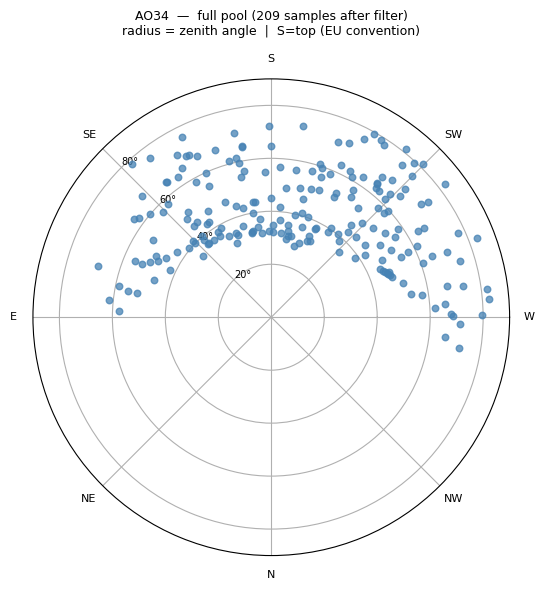

In [6]:
# EU convention: S=top  →  az_plot = 3π/2 − az_rad  (so South maps to +y in the polar plot)
_az_rad  = np.radians(all_azimuths)
_az_plot = 3 * np.pi / 2 - _az_rad
_zen     = 90.0 - all_elevations

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
ax.scatter(_az_plot, _zen, s=22, color="steelblue", alpha=0.75, zorder=4)
ax.set_rlim(0, 90)
ax.set_rticks([20, 40, 60, 80])
ax.set_yticklabels(["20°", "40°", "60°", "80°"], fontsize=7)
ax.set_rlabel_position(135)
ax.set_xticklabels(["W", "SW", "S", "SE", "E", "NE", "N", "NW"], fontsize=8)
ax.set_title(
    f"{HELIOSTAT_ID}  —  full pool ({N_TOTAL} samples after filter)\n"
    "radius = zenith angle  |  S=top (EU convention)",
    fontsize=9, pad=14,
)
plt.tight_layout()
plt.show()

## Helper Functions

In [7]:
from nb_utils import (
    snapshot_kinematics, restore_kinematics,
    setup_optimizer, apply_bounds, clip_and_step, reset_for_new_run,
    compute_mrad, current_base_pos, eval_mrad,
    active_pixel_percent, bitmap_centroid,
    val_alignment_loss, val_focal_loss,
)

print("Helpers loaded from nb_utils.")

Helpers loaded from nb_utils.


## Training Infrastructure

Replicates `WortbergKinematicReconstructor` internals explicitly so each step is inspectable.

In [8]:
# Optimizer setup, bounds clamping, and validation-loss helpers
# are all in nb_utils (imported in the helpers cell above).
print("Training infrastructure ready.")

Training infrastructure ready.


## Initial Kinematic Snapshot

Taken before any training. Used to reset the scenario to its clean state before each training size.

In [9]:
_hook_handles  = []   # managed across training sizes
_initial_snap  = snapshot_kinematics(heliostat_group.kinematics)

print("Initial parameter norms (should all be ≈0 for clean scenario):")
k = heliostat_group.kinematics
print(f"  translation:     {k.translation_deviation_parameters.norm().item():.6f}")
print(f"  rotation:        {k.rotation_deviation_parameters.norm().item():.6f}")
print(f"  actuator_angle:  {k.actuators.optimizable_parameters[:, indices.actuator_initial_angle, :].norm().item():.6f}")
print(f"  actuator_offset: {k.actuators.non_optimizable_parameters[:, indices.actuator_offset, :].norm().item():.6f}")

# Pre-training mrad on full pool (clean scenario vs. GT) as a reference baseline
scenario.set_number_of_rays(DISPLAY_RAYS)
_full_am = torch.tensor([N_TOTAL], device=device, dtype=torch.long)
_baseline_errs, _baseline_mean, _baseline_med = eval_mrad(
    all_rays, _full_am, all_target_mask, all_centroids,
    scenario=scenario, heliostat_group=heliostat_group,
    forward_pass_fn=_forward_pass, hel_dist_m=hel_dist_m, device=device
)
scenario.set_number_of_rays(TRAIN_RAYS)
print(f"\nBaseline (clean scenario, full pool): mean={_baseline_mean:.2f} mrad  median={_baseline_med:.2f} mrad")

Initial parameter norms (should all be ≈0 for clean scenario):
  translation:     0.175000
  rotation:        0.000000
  actuator_angle:  1.806936
  actuator_offset: 0.478076

Baseline (clean scenario, full pool): mean=3.13 mrad  median=2.78 mrad


## Training Loop

For each training size:
1. Azimuth-split the pool → train/val/test indices
2. Polar plot showing split assignment
3. Reset kinematics to clean state
4. Stage 1 — AlignmentLoss (motor-position MSE, no ray tracing)
5. Stage 2 — FocalSpotLoss (ray-traced centroid MSE, mini-batched)
6. Evaluate on test set
7. Intermediate plots (loss curves, accuracy table)


  TRAIN SIZE = 1   (val=100,  pool=209)
  Split sizes: train=1  val=108  test=100  [val↔test swapped]


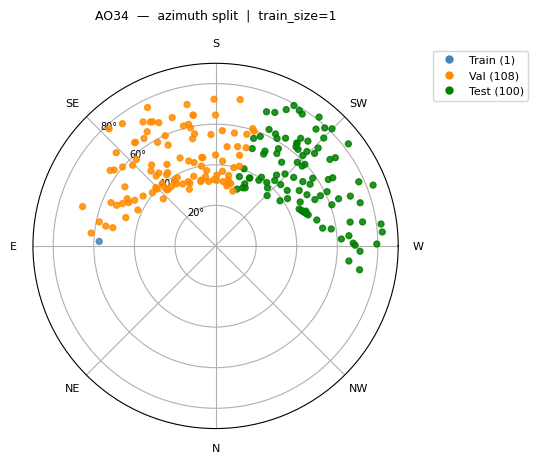

  Pre-training:  test mrad mean=3.541  median=3.149
  Stage 1: 20 epochs  |  1 train samples


  S1 n=1: 100%|██████████| 20/20 [00:00<00:00, 20.99it/s]


  After S1:      test mrad mean=12.374  median=13.093
  Stage 2: 100 epochs  |  1 train samples  |  1 mini-batch(es)


  S2 n=1:  12%|█▏        | 12/100 [00:10<01:20,  1.09it/s]

In [ ]:
results = {}

for train_size in TRAIN_SIZES:

    # ---- Feasibility check -----------------------------------------------
    if N_TOTAL < train_size + 2 * VAL_SIZE:
        print(f"\nSkipping train_size={train_size}: pool ({N_TOTAL}) < {train_size + 2*VAL_SIZE}")
        continue

    print(f"\n{'='*65}")
    print(f"  TRAIN SIZE = {train_size}   (val={VAL_SIZE},  pool={N_TOTAL})")
    print(f"{'='*65}")

    # ---- 1. Azimuth re-split --------------------------------------------------
    _split_df = DatasetSplitter._get_azimuth_splits(
        heliostat_df.copy(), training_size=train_size, validation_size=VAL_SIZE
    )
    train_idx = _split_df[_split_df[paint_mappings.SPLIT_KEY] == paint_mappings.TRAIN_INDEX].index.tolist()
    val_idx   = _split_df[_split_df[paint_mappings.SPLIT_KEY] == paint_mappings.VALIDATION_INDEX].index.tolist()
    test_idx  = _split_df[_split_df[paint_mappings.SPLIT_KEY] == paint_mappings.TEST_INDEX].index.tolist()

    if SWAP_VAL_TEST:
        val_idx, test_idx = test_idx, val_idx

    print(f"  Split sizes: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}"
          + ("  [val↔test swapped]" if SWAP_VAL_TEST else ""))

    def _slice(idx):
        t = torch.tensor(idx, device=device)
        return (
            all_flux[t], all_centroids[t], all_rays[t],
            all_motor_pos[t], all_target_mask[t],
            torch.tensor([len(idx)], device=device, dtype=torch.long),
        )

    s_flux, s_cents, s_rays, s_mp, s_tm, s_am = _slice(train_idx)
    v_flux, v_cents, v_rays, v_mp, v_tm, v_am = _slice(val_idx)
    t_flux, t_cents, t_rays, t_mp, t_tm, t_am = _slice(test_idx)

    # ---- 2. Polar plot of split assignment ------------------------------------
    _colors_all = np.full(N_TOTAL, "lightgray", dtype=object)
    for i in train_idx: _colors_all[i] = "steelblue"
    for i in val_idx:   _colors_all[i] = "darkorange"
    for i in test_idx:  _colors_all[i] = "green"

    fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw={"projection": "polar"})
    ax.scatter(3*np.pi/2 - np.radians(all_azimuths), 90 - all_elevations,
               s=18, c=list(_colors_all), alpha=0.85, zorder=4)
    ax.legend(handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor="steelblue",  markersize=7, label=f"Train ({len(train_idx)})"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor="darkorange", markersize=7, label=f"Val ({len(val_idx)})"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor="green",      markersize=7, label=f"Test ({len(test_idx)})"),
    ], loc="upper left", bbox_to_anchor=(1.08, 1.05), fontsize=8)
    ax.set_rlim(0, 90); ax.set_rticks([20, 40, 60, 80])
    ax.set_yticklabels(["20°","40°","60°","80°"], fontsize=7); ax.set_rlabel_position(135)
    ax.set_xticklabels(["W","SW","S","SE","E","NE","N","NW"], fontsize=8)
    ax.set_title(f"{HELIOSTAT_ID}  —  azimuth split  |  train_size={train_size}", fontsize=9, pad=14)
    plt.tight_layout(); plt.show()

    # ---- 3. Reset kinematics + build Stage 1 optimizer -----------------------
    reset_for_new_run(heliostat_group.kinematics, _initial_snap, _hook_handles)
    kinematic = heliostat_group.kinematics
    optimizer_s1, _hook_handles = setup_optimizer(kinematic, BASE_LR, device)
    scheduler_s1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s1, mode="min", factor=0.5, patience=10, threshold=1e-4, cooldown=5, min_lr=1e-8
    )
    alignment_loss_fn = AlignmentLoss()

    # ---- 4. Pre-training mrad on test set ------------------------------------
    scenario.set_number_of_rays(DISPLAY_RAYS)
    pre_errs, pre_mean, pre_med = eval_mrad(t_rays, t_am, t_tm, t_cents, scenario=scenario, heliostat_group=heliostat_group, forward_pass_fn=_forward_pass, hel_dist_m=hel_dist_m, device=device)
    scenario.set_number_of_rays(TRAIN_RAYS)
    print(f"  Pre-training:  test mrad mean={pre_mean:.3f}  median={pre_med:.3f}")

    # ---- 5. Stage 1 — AlignmentLoss ------------------------------------------
    s1_train_losses, s1_val_losses = [], []

    if not SKIP_STAGE1:
        print(f"  Stage 1: {STAGE1_EPOCHS} epochs  |  {len(train_idx)} train samples")
        for epoch in tqdm_nb(range(1, STAGE1_EPOCHS + 1), desc=f"  S1 n={train_size}"):
            optimizer_s1.zero_grad()
            kinematic = heliostat_group.kinematics

            heliostat_group.activate_heliostats(active_heliostats_mask=s_am, device=device)
            _bpd = kinematic._base_position_deviation              # [1, 3]
            _rep = _bpd.repeat_interleave(s_am, dim=0)             # [N_train, 3]
            kinematic.active_heliostat_positions = (
                kinematic.active_heliostat_positions
                + torch.cat([_rep, torch.zeros(_rep.shape[0], 1, device=device)], dim=1)
            )
            heliostat_group.align_surfaces_with_incident_ray_directions(
                aim_points=scenario.solar_tower.get_centers_of_target_areas(s_tm, device),
                incident_ray_directions=s_rays,
                active_heliostats_mask=s_am,
                device=device,
            )

            lps  = alignment_loss_fn(
                predicted_motor_positions=kinematic.active_motor_positions,
                measured_motor_positions=s_mp,
                actuators=kinematic.actuators,
                device=device,
            )   # [N_train]
            loss = lps.mean()
            loss.backward()
            clip_and_step(optimizer_s1, kinematic)
            s1_train_losses.append(loss.item())

            val_loss_s1 = val_alignment_loss(v_rays, v_am, v_tm, v_mp, kinematic, alignment_loss_fn, scenario=scenario, heliostat_group=heliostat_group, device=device)
            s1_val_losses.append(val_loss_s1)
            scheduler_s1.step(val_loss_s1)

        # ---- 6. After-S1 mrad on test set ----------------------------------------
        scenario.set_number_of_rays(DISPLAY_RAYS)
        s1_errs, s1_mean, s1_med = eval_mrad(t_rays, t_am, t_tm, t_cents, scenario=scenario, heliostat_group=heliostat_group, forward_pass_fn=_forward_pass, hel_dist_m=hel_dist_m, device=device)
        scenario.set_number_of_rays(TRAIN_RAYS)
        print(f"  After S1:      test mrad mean={s1_mean:.3f}  median={s1_med:.3f}")
    else:
        s1_errs, s1_mean, s1_med = pre_errs, pre_mean, pre_med
        print("  Stage 1 skipped — using pre-training values for s1 results.")


    # ---- 7. Stage 1 → Stage 2 transition ------------------------------------
    kinematic._base_position_deviation = (
        kinematic._base_position_deviation.detach().requires_grad_(True)
    )
    optimizer_s2 = torch.optim.Adam(
        [
            {"params": kinematic.translation_deviation_parameters,  "lr": BASE_LR * 5.0},
            {"params": kinematic.rotation_deviation_parameters,     "lr": BASE_LR},
            {"params": kinematic.actuators.optimizable_parameters,  "lr": BASE_LR},
            {"params": kinematic._base_position_deviation,          "lr": BASE_LR * 5.0},
        ],
        lr=BASE_LR,
    )
    scheduler_s2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_s2, mode="min", factor=0.5, patience=10, threshold=1e-4, cooldown=5, min_lr=1e-8
    )
    focal_loss_fn = FocalSpotLoss(scenario=scenario)

    # ---- 8. Stage 2 — FocalSpotLoss ------------------------------------------
    s2_train_losses, s2_val_losses = [], []
    n_mb = max(1, (len(train_idx) + MINI_BATCH_SIZE - 1) // MINI_BATCH_SIZE)

    print(f"  Stage 2: {STAGE2_EPOCHS} epochs  |  {len(train_idx)} train samples  |  {n_mb} mini-batch(es)")
    for epoch in tqdm_nb(range(1, STAGE2_EPOCHS + 1), desc=f"  S2 n={train_size}"):
        kinematic = heliostat_group.kinematics
        optimizer_s2.zero_grad()   # clear once per epoch; accumulate across mini-batches
        epoch_loss = 0.0

        for mb in range(n_mb):
            mb_s  = mb * MINI_BATCH_SIZE
            mb_e  = min(mb_s + MINI_BATCH_SIZE, len(train_idx))
            mb_sz = mb_e - mb_s

            mb_rays  = s_rays[mb_s:mb_e]
            mb_tm    = s_tm[mb_s:mb_e]
            mb_cents = s_cents[mb_s:mb_e]
            mb_am    = torch.tensor([mb_sz], device=device, dtype=torch.long)

            heliostat_group.activate_heliostats(active_heliostats_mask=mb_am, device=device)
            _bpd = kinematic._base_position_deviation
            _rep = _bpd.repeat_interleave(mb_am, dim=0)
            kinematic.active_heliostat_positions = (
                kinematic.active_heliostat_positions
                + torch.cat([_rep, torch.zeros(_rep.shape[0], 1, device=device)], dim=1)
            )
            heliostat_group.align_surfaces_with_incident_ray_directions(
                aim_points=scenario.solar_tower.get_centers_of_target_areas(mb_tm, device),
                incident_ray_directions=mb_rays,
                active_heliostats_mask=mb_am,
                device=device,
            )
            rt = HeliostatRayTracer(
                scenario=scenario, heliostat_group=heliostat_group,
                blocking_active=False, world_size=1, rank=0,
                batch_size=max(8, mb_sz),
                random_seed=0,
            )
            flux, _, _, _ = rt.trace_rays(
                incident_ray_directions=mb_rays,
                active_heliostats_mask=mb_am,
                target_area_indices=mb_tm,
                device=device,
            )
            # Undo sampler reordering so flux[i] corresponds to mb_rays[i]
            inv_perm = torch.argsort(rt.get_sampler_indices())
            flux_nat = flux[inv_perm]

            lps = focal_loss_fn(
                prediction=flux_nat,
                ground_truth=mb_cents,
                target_area_indices=mb_tm,
                reduction_dimensions=(indices.focal_spots,),
                device=device,
            )   # [mb_sz]

            # Weight by mini-batch fraction so gradients are correctly normalised
            mb_loss = lps.mean() * (mb_sz / len(train_idx))
            mb_loss.backward()
            epoch_loss += mb_loss.item()

        clip_and_step(optimizer_s2, kinematic)
        s2_train_losses.append(epoch_loss)

        val_loss_s2 = val_focal_loss(v_rays, v_am, v_tm, v_cents, focal_loss_fn, kinematic, scenario=scenario, heliostat_group=heliostat_group, device=device)
        s2_val_losses.append(val_loss_s2)
        scheduler_s2.step(val_loss_s2)

    # ---- 9. Final evaluation on test set -------------------------------------
    scenario.set_number_of_rays(DISPLAY_RAYS)
    final_errs, final_mean, final_med = eval_mrad(t_rays, t_am, t_tm, t_cents, scenario=scenario, heliostat_group=heliostat_group, forward_pass_fn=_forward_pass, hel_dist_m=hel_dist_m, device=device)
    scenario.set_number_of_rays(TRAIN_RAYS)
    print(f"  After S2:      test mrad mean={final_mean:.3f}  median={final_med:.3f}")

    # ---- 10. Store results ---------------------------------------------------
    results[train_size] = {
        "train_idx": train_idx, "val_idx": val_idx, "test_idx": test_idx,
        "pre":   {"mean": pre_mean,   "med": pre_med,   "per": pre_errs},
        "s1":    {"mean": s1_mean,    "med": s1_med,    "per": s1_errs},
        "final": {"mean": final_mean, "med": final_med, "per": final_errs},
        "s1_train": s1_train_losses, "s1_val": s1_val_losses,
        "s2_train": s2_train_losses, "s2_val": s2_val_losses,
        "final_params": {
            "translation":    kinematic.translation_deviation_parameters.detach().clone(),
            "rotation":       kinematic.rotation_deviation_parameters.detach().clone(),
            "actuator_angle": kinematic.actuators.optimizable_parameters[:, indices.actuator_initial_angle, :].detach().clone(),
            "base_position":  kinematic._base_position_deviation.detach().clone(),
        },
    }

    # ---- 11. Intermediate plots ----------------------------------------------

    # A. Loss curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    ep1 = range(1, STAGE1_EPOCHS + 1)
    ep2 = range(1, STAGE2_EPOCHS + 1)
    if not SKIP_STAGE1:
        axes[0].plot(ep1, s1_train_losses, lw=1.5, color="steelblue", label="train")
        axes[0].plot(ep1, s1_val_losses,   lw=1.5, color="darkorange", ls="--", label="val")
    else:
        axes[0].text(0.5, 0.5, "Stage 1 skipped", ha="center", va="center",
                     transform=axes[0].transAxes, fontsize=12, color="gray")
    axes[0].set(title=f"S1 AlignmentLoss [rad²]  |  n={train_size}",
                xlabel="Epoch", ylabel="Loss [rad²]")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].plot(ep2, s2_train_losses, lw=1.5, color="steelblue", label="train")
    axes[1].plot(ep2, s2_val_losses,   lw=1.5, color="darkorange", ls="--", label="val")
    axes[1].set(title=f"S2 FocalSpotLoss [m²]  |  n={train_size}",
                xlabel="Epoch", ylabel="Loss [m²]")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.suptitle(f"{HELIOSTAT_ID}  —  train_size={train_size}  —  loss curves", fontsize=10)
    plt.tight_layout(); plt.show()

    # B. Accuracy table
    print(f"\n  {'Stage':<22} {'Test mean mrad':>16} {'Test median mrad':>18}")
    print(f"  {'-'*58}")
    for label, key in [("Pre-training", "pre"), ("After Stage 1", "s1"), ("After Stage 2", "final")]:
        r = results[train_size][key]
        print(f"  {label:<22} {r['mean']:16.4f} {r['med']:18.4f}")

print("\nTraining sweep complete.")

## Summary: Learning Curve

Final test mrad vs. training set size — the primary scientific result.

In [ ]:
_sizes   = [s for s in TRAIN_SIZES if s in results]
_pre_m   = [results[s]["pre"]["mean"]   for s in _sizes]
_pre_med = [results[s]["pre"]["med"]    for s in _sizes]
_s1_m    = [results[s]["s1"]["mean"]    for s in _sizes]
_s1_med  = [results[s]["s1"]["med"]     for s in _sizes]
_fin_m   = [results[s]["final"]["mean"] for s in _sizes]
_fin_med = [results[s]["final"]["med"]  for s in _sizes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for ax, vals_m, vals_med, title in [
    (axes[0], _fin_m,  _fin_med,  "After Stage 2 (FocalSpotLoss)"),
    (axes[1], _s1_m,   _s1_med,   "After Stage 1 (AlignmentLoss)"),
]:
    ax.semilogx(_sizes, vals_m,  "o-", lw=2, color="steelblue",  label="mean")
    ax.semilogx(_sizes, vals_med,"s--",lw=2, color="steelblue",  label="median", alpha=0.7)
    ax.axhline(_baseline_mean, color="gray", ls=":", lw=1.5, label=f"baseline mean ({_baseline_mean:.1f})")
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Test focal-spot error [mrad]")
    ax.set_title(f"{HELIOSTAT_ID}  —  {title}")
    ax.set_xticks(_sizes); ax.set_xticklabels([str(s) for s in _sizes])
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'n':>5} {'Pre mean':>10} {'S1 mean':>9} {'Final mean':>11} {'Final med':>10}")
print("-" * 50)
for s in _sizes:
    r = results[s]
    print(f"{s:>5}  {r['pre']['mean']:9.3f}  {r['s1']['mean']:8.3f}  {r['final']['mean']:10.3f}  {r['final']['med']:9.3f}")

## Summary: Sample Coverage Polar Grid

Shows which sun positions are assigned to train (blue) vs. test (green) for each training size.
Val (orange) is always the same high-azimuth samples.

In [ ]:
_valid_sizes = [s for s in TRAIN_SIZES if s in results]
_ncols = min(4, len(_valid_sizes))
_nrows = (len(_valid_sizes) + _ncols - 1) // _ncols

fig, axes = plt.subplots(
    _nrows, _ncols,
    figsize=(_ncols * 3.2, _nrows * 3.2),
    subplot_kw={"projection": "polar"},
    squeeze=False,
)

_az_p_all = 3*np.pi/2 - np.radians(all_azimuths)
_zen_all  = 90 - all_elevations

for idx_s, ts in enumerate(_valid_sizes):
    ax = axes[idx_s // _ncols][idx_s % _ncols]
    r  = results[ts]

    _c = np.full(N_TOTAL, "lightgray", dtype=object)
    for i in r["train_idx"]: _c[i] = "steelblue"
    for i in r["val_idx"]:   _c[i] = "darkorange"
    for i in r["test_idx"]:  _c[i] = "green"

    ax.scatter(_az_p_all, _zen_all, s=12, c=list(_c), alpha=0.85, zorder=4)
    ax.set_rlim(0, 90); ax.set_rticks([45, 80])
    ax.set_yticklabels([]); ax.set_xticklabels([])
    ax.set_title(f"n={ts}  final={r['final']['mean']:.2f} mrad", fontsize=8, pad=8)

# Hide empty subplots
for idx_s in range(len(_valid_sizes), _nrows * _ncols):
    axes[idx_s // _ncols][idx_s % _ncols].set_visible(False)

fig.suptitle(
    f"{HELIOSTAT_ID}  —  azimuth split coverage per training size\n"
    "blue=train  orange=val  green=test",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## Parameter Recovery Comparison

For each parameter group, shows how close the converged parameters are to the GT perturbation
as training size grows. Only shown when GT perturbations are known.

- **Solid lines**: L2 norm of recovery error `|converged - GT|` per group, vs. training size
- **Bar plot (last cell)**: GT value vs. recovered value per component, for the largest training size

In [ ]:
if pert_tensors is None:
    print("Real mode: GT perturbations unknown — parameter recovery comparison skipped.")
else:
    _sizes = [s for s in TRAIN_SIZES if s in results]

    # Clean-scenario baseline (absolute values from the scenario file).
    # apply_perturbations ADDS a delta, so the correct deviation recovered is
    # (p_recovered - p_clean).  Subtracting the GT perturbation gives the
    # residual error: 0 = perfect recovery.
    _baseline = {
        "translation":     _initial_snap["translation"][0].cpu().numpy(),
        "rotation":        _initial_snap["rotation"][0].cpu().numpy(),
        "actuator_angle":  _initial_snap["opt_params"][0, indices.actuator_initial_angle, :].cpu().numpy(),
        "actuator_offset": _initial_snap["nonopt_params"][0, indices.actuator_offset, :].cpu().numpy(),
        "base_position":   np.zeros(3),
    }

    # (key, subplot-title, unit-label, scale, component-labels)
    _groups = [
        ("translation",     "Translation",     "mm",   1000.0, [f"t{i}" for i in range(9)]),
        ("rotation",        "Rotation",        "mrad", 1000.0, [f"r{i}" for i in range(4)]),
        ("actuator_angle",  "Actuator angle",  "mrad", 1000.0, ["a0", "a1"]),
        ("actuator_offset", "Actuator offset", "mm",   1000.0, ["c0", "c1"]),
        ("base_position",   "Base position",   "mm",   1000.0, ["E", "N", "U"]),
    ]

    fig, axes = plt.subplots(1, len(_groups), figsize=(4.5 * len(_groups), 4.5))

    for ax, (key, title, unit, scale, comp_labels) in zip(axes, _groups):
        n_comp  = len(comp_labels)
        colors  = plt.cm.tab10(np.linspace(0, 0.9, min(n_comp, 10)))
        gt_flat = pert_tensors[key][0].cpu().numpy().flatten() * scale

        for ci, label in enumerate(comp_labels):
            # Residual error per training size: 0 = perfect recovery
            residuals = np.array([
                (results[s]["final_params"][key][0].cpu().numpy().flatten()[ci]
                 - _baseline[key].flatten()[ci]) * scale - gt_flat[ci]
                for s in _sizes
            ])
            ax.plot(_sizes, residuals, "o-", color=colors[ci], lw=1.8, ms=5, label=label)

        ax.axhline(0, color="black", lw=1.0, ls="--", alpha=0.5, zorder=0)
        ax.set_xscale("log")
        ax.set_xticks(_sizes)
        ax.set_xticklabels([str(s) for s in _sizes], fontsize=7, rotation=45)
        ax.set_xlabel("Training size", fontsize=8)
        ax.set_ylabel(f"Error [{unit}]", fontsize=8)
        ax.set_title(title, fontsize=9, pad=6)
        ax.legend(fontsize=7, ncol=2 if n_comp > 4 else 1, loc="best")
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

    plt.suptitle(
        f"{HELIOSTAT_ID}  \u2014  parameter recovery residual vs. training size\n"
        "(p\u2099\u209c\u209b \u2212 p\u2099\u2099\u2099\u2099) \u2212 \u0394p\u2c7c\u2c7c  |  "
        "0 = perfect recovery",
        fontsize=9, y=1.02,
    )
    plt.tight_layout()
    plt.show()

    # Numeric table
    print("\nResidual per group  [(p_rec - p_clean) - p_GT]  in mrad or mm:")
    _hdr_fmt = "{:>5}  " + "{:>16}" * len(_groups)
    print(_hdr_fmt.format("n", *[g[1][:14] for g in _groups]))
    print("-" * (7 + 16 * len(_groups)))
    for s in _sizes:
        fp  = results[s]["final_params"]
        row = [s]
        for key, _, unit, scale, _ in _groups:
            rec_dev = (fp[key][0].cpu().numpy().flatten() - _baseline[key].flatten()) * scale
            gt_pert = pert_tensors[key][0].cpu().numpy().flatten() * scale
            row.append(float(np.linalg.norm(rec_dev - gt_pert)))
        print(("{:>5}  " + "{:>16.4f}" * len(_groups)).format(*row))


In [ ]:
if pert_tensors is None:
    print("Real mode: GT perturbations unknown — skipped.")
elif not results:
    print("results is empty — run the training loop first.")
else:
    _best = max(results.keys())   # highest training size actually completed
    fp    = results[_best]["final_params"]

    _groups = [
        ("translation",     "Translation",     "mm",   1000.0, [f"t{i}" for i in range(9)]),
        ("rotation",        "Rotation",        "mrad", 1000.0, [f"r{i}" for i in range(4)]),
        ("actuator_angle",  "Actuator angle",  "mrad", 1000.0, ["a0", "a1"]),
        ("actuator_offset", "Actuator offset", "mm",   1000.0, ["c0", "c1"]),
        ("base_position",   "Base position",   "mm",   1000.0, ["E", "N", "U"]),
    ]

    fig, axes = plt.subplots(1, len(_groups), figsize=(4.2 * len(_groups), 4.0))

    for ax, (key, title, unit, scale, comp_labels) in zip(axes, _groups):
        n_comp = len(comp_labels)
        x      = np.arange(n_comp)
        w      = 0.35

        gt_vals  = pert_tensors[key][0].cpu().numpy().flatten() * scale
        rec_devs = (fp[key][0].cpu().numpy().flatten()
                    - _baseline[key].flatten()) * scale

        ax.bar(x - w/2, gt_vals,  width=w, color="steelblue", alpha=0.85, label="GT perturbation")
        ax.bar(x + w/2, rec_devs, width=w, color="darkorange", alpha=0.85, label=f"Recovered (n={_best})")

        ax.axhline(0, color="black", lw=0.7, ls="--", alpha=0.4)
        ax.set_xticks(x)
        ax.set_xticklabels(comp_labels, fontsize=8)
        ax.set_ylabel(f"[{unit}]", fontsize=8)
        ax.set_title(title, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.25, axis="y")
        if ax is axes[0]:
            ax.legend(fontsize=8)

    plt.suptitle(
        f"{HELIOSTAT_ID}  \u2014  GT perturbation vs. recovered deviation  (n={_best} train samples)\n"
        "blue = applied perturbation  |  orange = what the optimizer converged to",
        fontsize=9,
    )
    plt.tight_layout()
    plt.show()


## GT vs. Predicted Parameters (JSON)

Raw numeric values for both the GT perturbations and the recovered deviations at the best training size.
All values are in the model's native units (metres for translations/offsets/base_position, radians for rotations/actuator angles).

In [ ]:
if pert_tensors is None:
    print("Real mode: GT perturbations unknown — JSON comparison skipped.")
elif not results:
    print("results is empty — run the training loop first.")
else:
    _best = max(results.keys())
    fp    = results[_best]["final_params"]

    def _arr(t):
        """Tensor or ndarray → flat numpy array."""
        if isinstance(t, torch.Tensor):
            return t.detach().cpu().numpy().flatten()
        return np.asarray(t).flatten()

    gt_json = {
        "translation_m":      _arr(pert_tensors["translation"][0]).tolist(),
        "rotation_rad":       _arr(pert_tensors["rotation"][0]).tolist(),
        "actuator_angle_rad": _arr(pert_tensors["actuator_angle"][0]).tolist(),
        "actuator_offset_m":  _arr(pert_tensors["actuator_offset"][0]).tolist(),
        "base_position_m":    _arr(pert_tensors["base_position"][0]).tolist(),
    }

    pred_json = {
        "translation_m":      (_arr(fp["translation"][0]) - _arr(_baseline["translation"])).tolist(),
        "rotation_rad":       (_arr(fp["rotation"][0])    - _arr(_baseline["rotation"])).tolist(),
        "actuator_angle_rad": (_arr(fp["actuator_angle"][0]) - _arr(_baseline["actuator_angle"])).tolist(),
        "actuator_offset_m":  (_arr(fp["actuator_offset"][0]) - _arr(_baseline["actuator_offset"])).tolist(),
        "base_position_m":    _arr(fp["base_position"][0]).tolist(),
    }

    combined = {
        f"gt_perturbations (applied to scenario)": gt_json,
        f"predicted_deviations (n={_best} train samples)": pred_json,
    }

    print(json.dumps(combined, indent=2))